<a href="https://colab.research.google.com/gist/francischisom/388a26c9c06d9a99ef2e27c3f6a8a143/baseline_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Baseline Models — LR · Random Forest · XGBoost


> Baselines set the bar every advanced model must beat. They are fast,
> interpretable, and tell us how far simple surface features can go on
> adverse-drug-event detection.



Dependencies: `baseline_models.py`, `eval_utils.py`, and the split CSVs
(`train.csv`, `val.csv`, `test.csv`, `unified_full.csv`).

##  Setup & important installations

In [ ]:
!pip install -q numpy pandas scikit-learn xgboost matplotlib seaborn

In [ ]:
import sys; sys.path.append('.')
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc

import eval_utils as ev
import baseline_models as bm

logging.basicConfig(level=logging.INFO, format='[%(levelname)s] %(message)s')
NAVY, RED, GREEN, GRAY = '#00002D', '#C44E52', '#2E8B57', '#4C72B0'

In [ ]:
# Load the splits produced by the preprocessing notebook
train_df, val_df, test_df, full_df = ev.load_splits(
    'train.csv', 'val.csv', 'test.csv', 'unified_full.csv')

# uids let us hand probabilities for ensembling
val_df = ev.add_uid(val_df)
test_df = ev.add_uid(test_df)
print('Train', train_df.shape, '| Val', val_df.shape,
      '| Test', test_df.shape)
print('Class balance (train):',
      train_df[ev.LABEL_COL].value_counts(normalize=True).round(3).to_dict())

Train (2156, 8) | Val (470, 9) | Test (451, 9)
Class balance (train): {1: 0.6, 0: 0.4}


## Train & evaluate all baselines
`bm.evaluate_all` fits each model on **train**, evaluates on **test**, and
(because we pass `val_df`) also stores validation probabilities for the
ensemble handoff. Every model is a `Pipeline(TF-IDF → classifier)`, so the
vectoriser never sees the test split.

In [ ]:
results, artefacts = bm.evaluate_all(train_df, test_df, val_df)
results.round(4)

,model,accuracy,precision,recall,f1,f1_macro,roc_auc
0,LogReg,0.9823,0.9747,0.9963,0.9854,0.9814,0.9954
1,RandomForest,0.9712,0.9574,0.9963,0.9765,0.9696,0.9948
2,XGBoost,0.9645,0.9636,0.9779,0.9707,0.9629,0.9918


**Functionality note.** `evaluate_all` also runs cleanly if you omit
`val_df` (it simply skips the validation probabilities) — a deliberate
edge-case the reviewer's framework asks for.

##  Model comparison (visualization)

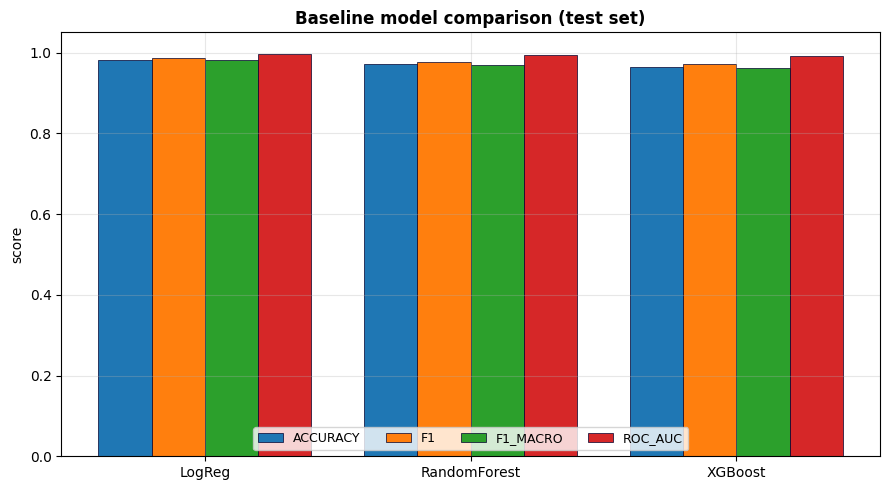

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
metrics = ['accuracy', 'f1', 'f1_macro', 'roc_auc']
x = np.arange(len(results)); w = 0.2
for k, m in enumerate(metrics):
    ax.bar(x + (k - 1.5) * w, results[m], width=w, label=m.upper(),
           edgecolor=NAVY, linewidth=0.5)
ax.set_xticks(x); ax.set_xticklabels(results['model'])
ax.set_ylim(0, 1.05); ax.set_ylabel('score')
ax.set_title('Baseline model comparison (test set)', fontweight='bold')
ax.legend(ncol=4, fontsize=9, loc='lower center')
plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('baseline_comparison.png', dpi=200)
plt.show()

##  Confusion matrices
In pharmacovigilance the **false negative (missed ADE, bottom-left)** is
the dangerous error — we read it on every model.

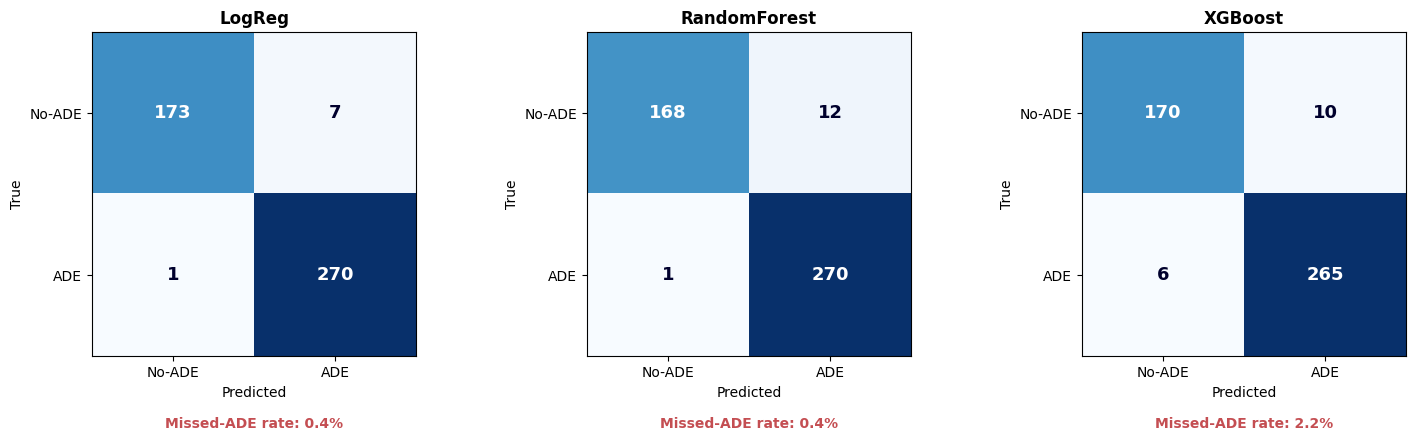

In [ ]:
fig, axes = plt.subplots(1, len(artefacts),
                         figsize=(5 * len(artefacts), 4.5))
if len(artefacts) == 1:
    axes = [axes]
y_true = test_df[ev.LABEL_COL].values
for ax, (name, art) in zip(axes, artefacts.items()):
    pred = (art['test_proba'] >= 0.5).astype(int)
    cm = confusion_matrix(y_true, pred)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['No-ADE', 'ADE'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['No-ADE', 'ADE'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(name, fontweight='bold')
    thr = cm.max() / 2
    for i in range(2):
        for j in range(2):
            ax.text(j, i, format(cm[i, j], 'd'), ha='center',
                    va='center', fontweight='bold', fontsize=13,
                    color='white' if cm[i, j] > thr else NAVY)
    tn, fp, fn, tp = cm.ravel()
    miss = fn / (fn + tp) if (fn + tp) else 0
    ax.text(0.5, -0.22, f'Missed-ADE rate: {miss:.1%}',
            transform=ax.transAxes, ha='center', color=RED,
            fontweight='bold')
plt.tight_layout(); plt.savefig('baseline_confusion.png', dpi=200)
plt.show()

##  ROC curves

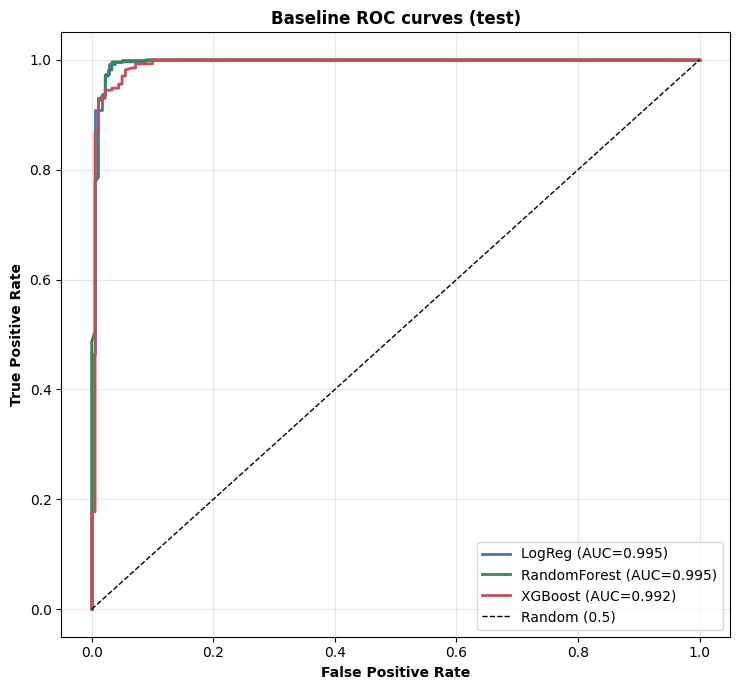

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 7))
palette = {'LogReg': GRAY, 'RandomForest': GREEN, 'XGBoost': RED}
for name, art in artefacts.items():
    fpr, tpr, _ = roc_curve(y_true, art['test_proba'])
    ax.plot(fpr, tpr, lw=2, color=palette.get(name),
            label=f'{name} (AUC={auc(fpr, tpr):.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (0.5)')
ax.set_xlabel('False Positive Rate', fontweight='bold')
ax.set_ylabel('True Positive Rate', fontweight='bold')
ax.set_title('Baseline ROC curves (test)', fontweight='bold')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('baseline_roc.png', dpi=200); plt.show()

## Interpretability : what drives the predictions

Because baselines are transparent, we can read the evidence directly:
signed coefficients for Logistic Regression, feature importances for the
tree models. The ADE-side tokens should always be clinical symptom words.

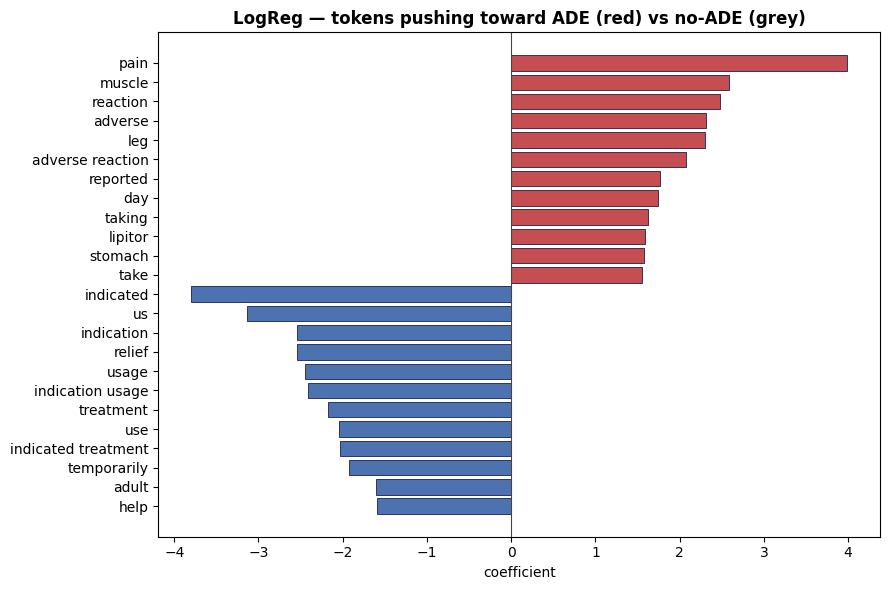

In [ ]:
# Logistic Regression: signed coefficients (ADE-side vs no-ADE-side)
pos, neg = bm.top_features(artefacts['LogReg']['pipeline'], n=12)
fig, ax = plt.subplots(figsize=(9, 6))
toks = [t for t, _ in neg][::-1] + [t for t, _ in pos][::-1]
vals = [v for _, v in neg][::-1] + [v for _, v in pos][::-1]
colors = [GRAY if v < 0 else RED for v in vals]
ax.barh(toks, vals, color=colors, edgecolor=NAVY, linewidth=0.5)
ax.axvline(0, color='#444', lw=0.8)
ax.set_title('LogReg — tokens pushing toward ADE (red) vs no-ADE (grey)',
             fontweight='bold')
ax.set_xlabel('coefficient')
plt.tight_layout(); plt.savefig('baseline_logreg_features.png', dpi=200)
plt.show()

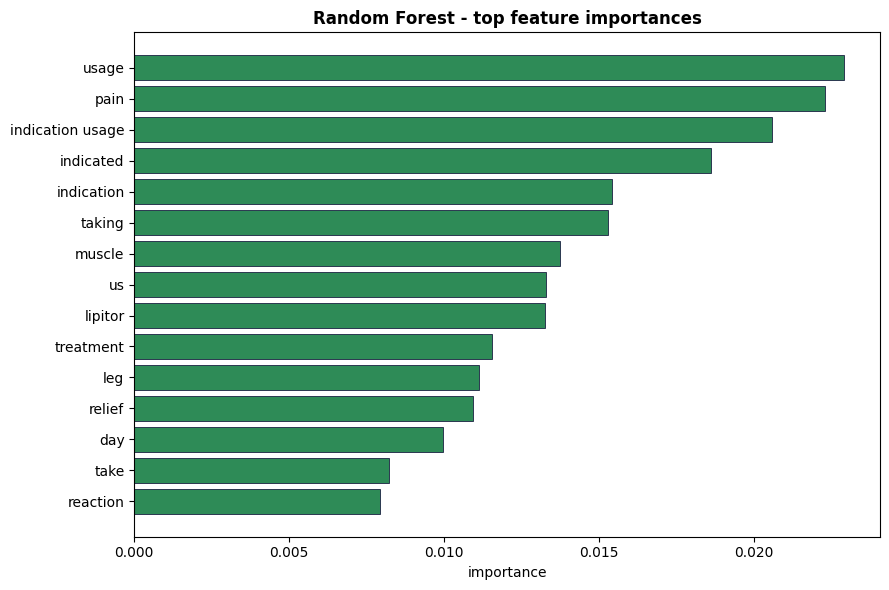

In [ ]:
# Tree-model importances (Random Forest shown; XGBoost analogous)
if 'RandomForest' in artefacts:
    imp, _ = bm.top_features(artefacts['RandomForest']['pipeline'], n=15)
    toks = [t for t, _ in imp][::-1]
    vals = [v for _, v in imp][::-1]
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(toks, vals, color=GREEN, edgecolor=NAVY, linewidth=0.5)
    ax.set_title('Random Forest - top feature importances',
                 fontweight='bold')
    ax.set_xlabel('importance')
    plt.tight_layout()
    plt.savefig('baseline_rf_features.png', dpi=200); plt.show()

### Cross domain on the baseline models (LG,RF and XGBOOST)

       model  f1_standard  f1_cross  degradation_pct
      LogReg       0.9854    0.9855             -0.0
RandomForest       0.9765    0.9996             -2.4
     XGBoost       0.9707    0.9938             -2.4


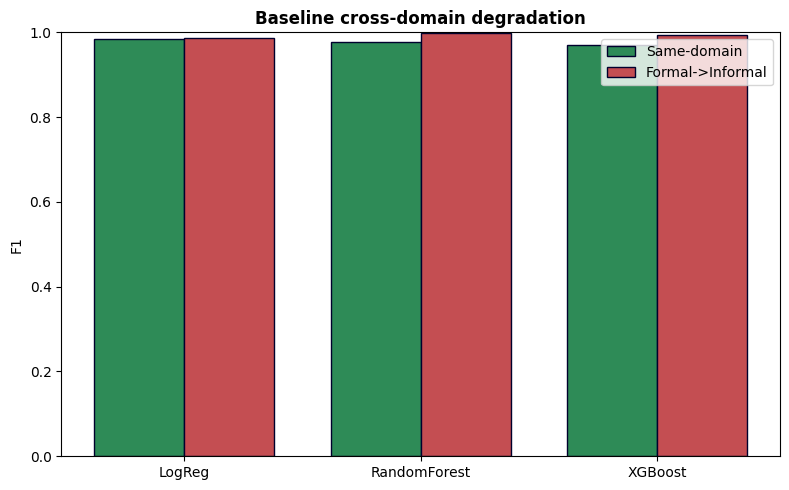

In [ ]:
gap_rows = []
for name in artefacts:
    same = results.loc[results['model'] == name, 'f1'].iloc[0]
    cross = bm.run_cross_domain(full_df, name, 'Formal', 'Informal')['f1']
    gap_rows.append(ev.degradation_row(name, same, cross))
gap = pd.DataFrame(gap_rows)
print(gap.to_string(index=False))

x = np.arange(len(gap)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w / 2, gap['f1_standard'], width=w, label='Same-domain',
       color=GREEN, edgecolor=NAVY)
ax.bar(x + w / 2, gap['f1_cross'], width=w, label='Formal->Informal',
       color=RED, edgecolor=NAVY)
ax.set_xticks(x); ax.set_xticklabels(gap['model'])
ax.set_ylim(0, 1); ax.set_ylabel('F1')
ax.set_title('Baseline cross-domain degradation', fontweight='bold')
ax.legend()
plt.tight_layout(); plt.savefig('baseline_gap.png', dpi=200); plt.show()

##  Export for the ensembling  + leaderboard
We write the same uid-keyed artefacts the advanced models produce, so the
integrator can merge baselines and advanced models on a level field.

In [ ]:
results.to_csv('metrics_baselines.csv', index=False)
gap.to_csv('gap_baselines.csv', index=False)

name_map = {'LogReg': 'logreg', 'RandomForest': 'rf', 'XGBoost': 'xgb'}
for name, art in artefacts.items():
    key = name_map.get(name, name.lower())
    ev.save_probabilities(test_df, art['test_proba'], key,
                          f'probs_{key}_test.csv')
    if 'val_proba' in art:
        ev.save_probabilities(val_df, art['val_proba'], key,
                              f'probs_{key}_val.csv')
print('Saved metrics_baselines.csv, gap_baselines.csv, and uid-keyed '
      'probability CSVs.')

Saved 451 probabilities -> probs_logreg_test.csv
Saved 470 probabilities -> probs_logreg_val.csv
Saved 451 probabilities -> probs_rf_test.csv
Saved 470 probabilities -> probs_rf_val.csv
Saved 451 probabilities -> probs_xgb_test.csv
Saved 470 probabilities -> probs_xgb_val.csv
Saved metrics_baselines.csv, gap_baselines.csv, and uid-keyed probability CSVs.
